# Práctica 1 — Modelo de pérdidas de la cartera
## Matemáticas Actuariales para Seguro de Daños, Fianzas y Reaseguro · UNAM


## 1. Cargar datos y explorar las variables de interés

Para esta práctica se utilizan únicamente las variables necesarias para frecuencia, severidad y transformación contractual. Los factores de riesgo se reservan para la Práctica 2 (GLM).

In [13]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

np.random.seed(0)
plt.rcParams['figure.figsize'] = (8, 3.6)

df = pd.read_parquet("../inputs/cartera.parquet")
print('Pólizas:', len(df), '| Columnas:', len(df.columns))

print('\nVariables utilizadas:')
print('  frecuencia : num_siniestros, exposicion')
print('  severidad  : monto_promedio_siniestro (ground-up)')
print('  póliza     : deducible, suma_asegurada, coaseguro (transformación)')
print('  No se usan aquí: edad_conductor, sexo, antiguedad_vehiculo, tipo_vehiculo, uso, zona.')

Pólizas: 30000 | Columnas: 14

Variables utilizadas:
  frecuencia : num_siniestros, exposicion
  severidad  : monto_promedio_siniestro (ground-up)
  póliza     : deducible, suma_asegurada, coaseguro (transformación)
  No se usan aquí: edad_conductor, sexo, antiguedad_vehiculo, tipo_vehiculo, uso, zona.


% de pólizas con siniestro : 23.2%
Exposición total           : 23,993 años-póliza
Siniestros totales         : 8,834
Severidad media            : 52,471.29
Severidad mediana          : 33,938.17
Desviación estándar        : 63,573.20
P99 de severidad           : 307,974.40


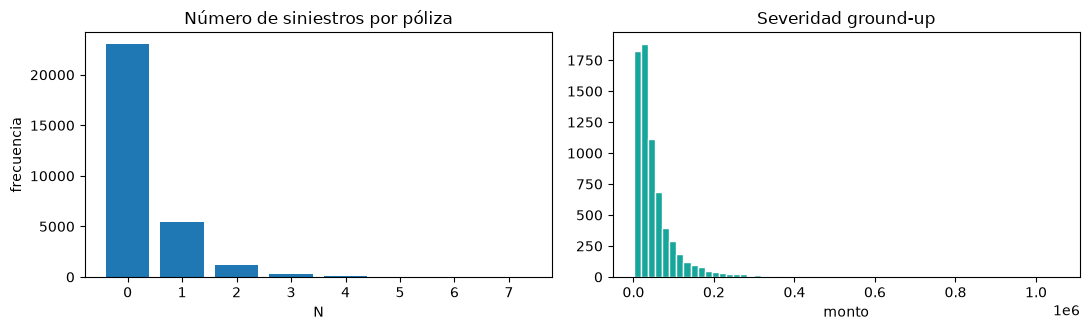

In [16]:
con = df[df.num_siniestros > 0].copy()

print(f"% de pólizas con siniestro : {(df.num_siniestros > 0).mean():.1%}")
print(f"Exposición total           : {df.exposicion.sum():,.0f} años-póliza")
print(f"Siniestros totales         : {df.num_siniestros.sum():,.0f}")
print(f"Severidad media            : {con.monto_promedio_siniestro.mean():,.2f}")
print(f"Severidad mediana          : {con.monto_promedio_siniestro.median():,.2f}")
print(f"Desviación estándar        : {con.monto_promedio_siniestro.std():,.2f}")
print(f"P99 de severidad           : {np.percentile(con.monto_promedio_siniestro,99):,.2f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
vals, counts = np.unique(df.num_siniestros, return_counts=True)
ax[0].bar(vals, counts)
ax[0].set_title('Número de siniestros por póliza')
ax[0].set_xlabel('N')
ax[0].set_ylabel('frecuencia')
ax[1].hist(con.monto_promedio_siniestro, bins=60, color="#17A69B", edgecolor="white")
ax[1].set_title('Severidad ground-up')
ax[1].set_xlabel('monto')
plt.tight_layout()
plt.show()

## 2. Severidad

Se ajustan Lognormal, Gamma, Weibull y Pareto. La elección no se realiza únicamente por AIC: también se revisa el comportamiento de la cola mediante la supervivencia.

In [17]:
x = con.monto_promedio_siniestro.to_numpy(float)

def aic(dist, pr, d):
    return 2*len(d) - 2*np.sum(dist.logpdf(d, *pr))

cand = {
    'Lognormal': stats.lognorm,
    'Gamma': stats.gamma,
    'Weibull': stats.weibull_min,
    'Pareto': stats.pareto
}

ajustes, filas = {}, []
for nom, dist in cand.items():
    pr = dist.fit(x, floc=0)
    ajustes[nom] = (dist, pr)
    filas.append({'Distribución': nom,
                  'AIC': aic(dist, pr, x),
                  'Media': dist.mean(*pr),
                  'P99': dist.ppf(.99, *pr),
                  'P99.9': dist.ppf(.999, *pr)})

tabla = pd.DataFrame(filas).sort_values('AIC').reset_index(drop=True)
print(tabla.to_string(index=False, formatters={'AIC':'{:,.1f}'.format,
                                                'Media':'{:,.2f}'.format,
                                                'P99':'{:,.2f}'.format,
                                                'P99.9':'{:,.2f}'.format}))
mejor = tabla.iloc[0]['Distribución']
print(f'\n→ Elegida por AIC: {mejor}')

Distribución       AIC     Media              P99                 P99.9
   Lognormal 177,711.8 52,510.20       304,300.43            628,114.45
       Gamma 178,658.6 52,471.29       216,140.95            316,055.22
     Weibull 178,828.6 52,656.58       229,026.28            336,512.96
      Pareto 189,270.4       inf 5,151,112,344.22 10,588,871,546,529.65

→ Elegida por AIC: Lognormal


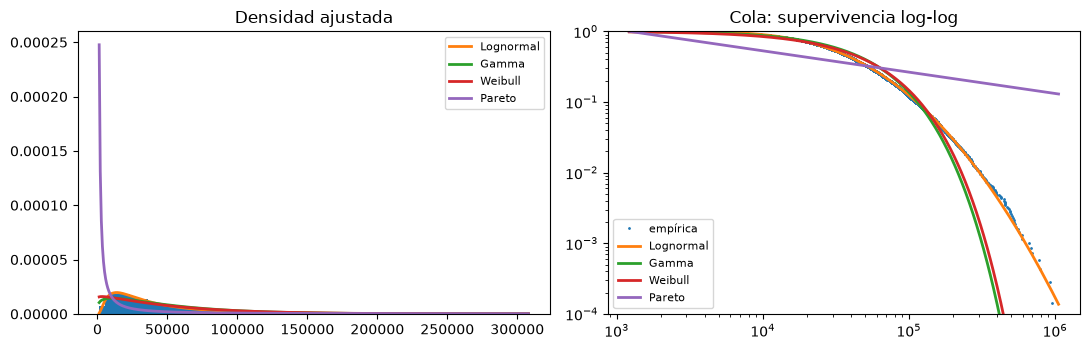

E[X] ground-up, modelo Lognormal: 52,510


In [20]:
# ─── Diagnóstico de la cola (densidad + supervivencia) ─────────────────────
dist_sev, pr_sev = ajustes[mejor]
p99 = np.percentile(x, 99)
grid = np.linspace(x.min(), p99, 400)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].hist(x, bins=70, density=True, range=(x.min(), p99))
for nom, (d, pr) in ajustes.items():
    ax[0].plot(grid, d.pdf(grid, *pr), lw=2, label=nom)
ax[0].set_title('Densidad ajustada')
ax[0].legend(fontsize=8)

xs = np.sort(x)
S_emp = 1 - np.arange(1, len(xs)+1)/len(xs)
ax[1].plot(xs, S_emp, '.', ms=2, label='empírica')
for nom, (d, pr) in ajustes.items():
    ax[1].plot(xs, d.sf(xs, *pr), lw=2, label=nom)
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].set_ylim(1e-4, 1)
ax[1].set_title('Cola: supervivencia log-log')
ax[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f'E[X] ground-up, modelo {mejor}: {dist_sev.mean(*pr_sev):,.0f}')

### Ground-up vs. severidad que paga la aseguradora

Los datos de severidad utilizados para el ajuste son **ground-up**, es decir, representan el daño real. Para obtener una aproximación de lo que paga la aseguradora se aplica, posteriormente, el deducible, el coaseguro y el límite dado por la suma asegurada. Esto evita ajustar la distribución de severidad directamente sobre montos ya transformados.

In [22]:
def transformar(x, ded, coas, sa):
    return np.minimum(np.maximum(x - ded, 0) * (1 - coas), sa)

pagado = transformar(x,
                     con.deducible.to_numpy(),
                     con.coaseguro.to_numpy(),
                     con.suma_asegurada.to_numpy())

print(f'E[X] ground-up    : {x.mean():,.0f}')
print(f'E[X] transformada : {pagado.mean():,.0f}')
print(f'Mediana transformada: {np.median(pagado):,.0f}')
print(f'Proporción que queda en cero por el deducible: {(pagado == 0).mean():.1%}')
print(f'Reducción media de severidad: {1-pagado.mean()/x.mean():.1%}')

E[X] ground-up    : 52,471
E[X] transformada : 34,723
Mediana transformada: 16,366
Proporción que queda en cero por el deducible: 25.4%
Reducción media de severidad: 33.8%


## 3. Frecuencia

Se ajustan Poisson, quasi-Poisson como diagnóstico de dispersión y binomial negativa. 

In [23]:
y = df.num_siniestros.to_numpy(int)
off = np.log(df.exposicion.to_numpy(float))
Xc = np.ones((len(df), 1))

pois = sm.GLM(y, Xc, family=sm.families.Poisson(), offset=off).fit()
quasi = sm.GLM(y, Xc, family=sm.families.Poisson(), offset=off).fit(scale='X2')
nb = sm.NegativeBinomial(y, Xc, offset=off).fit(disp=0)

lam_hat = np.exp(pois.params[0])
phi = quasi.scale
indice_disp = y.var() / y.mean()

print(f'Tasa λ̂ (siniestros por año-póliza) = {lam_hat:.6f}')
print(f'Índice de dispersión Var(N)/E[N]   = {indice_disp:.6f}')
print(f'Factor de dispersión φ (quasi)      = {phi:.6f}')
print(f'AIC Poisson                         = {pois.aic:,.2f}')
print(f'AIC Binomial negativa               = {nb.aic:,.2f}')

Tasa λ̂ (siniestros por año-póliza) = 0.368187
Índice de dispersión Var(N)/E[N]   = 1.249794
Factor de dispersión φ (quasi)      = 1.235040
AIC Poisson                         = 42,040.13
AIC Binomial negativa               = 41,449.10


P(N=0) observada       = 0.768333
P(N=0) esperada Poisson= 0.745663
P(N=0) esperada NB     = 0.768409


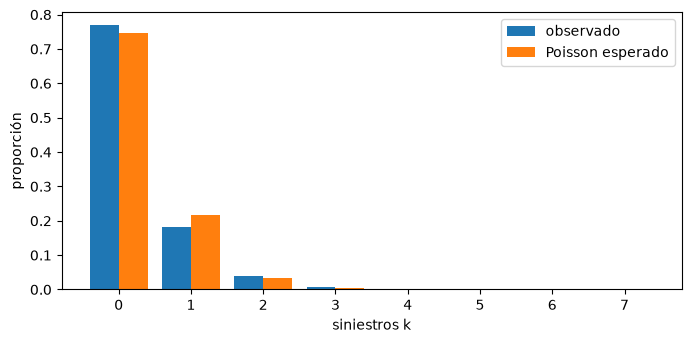

Decisión: hay sobredispersión (φ>1) y la NB baja el AIC → elijo BINOMIAL NEGATIVA.


In [25]:
# ─── Diagnóstico de exceso de ceros + observado vs. esperado ───────────────
mu_i = lam_hat * df.exposicion.to_numpy(float)
ceros_obs = (y == 0).mean()
ceros_esp_pois = np.exp(-mu_i).mean()

alpha = float(nb.params[-1])
mu_nb = np.exp(nb.params[0] + off)
ceros_esp_nb = ((1 + alpha*mu_nb) ** (-1/alpha)).mean()

print(f'P(N=0) observada       = {ceros_obs:.6f}')
print(f'P(N=0) esperada Poisson= {ceros_esp_pois:.6f}')
print(f'P(N=0) esperada NB     = {ceros_esp_nb:.6f}')

kmax = y.max()
ks = np.arange(kmax+1)
obs = np.bincount(y, minlength=kmax+1) / len(y)
esp_pois = np.array([stats.poisson(mu_i).pmf(k).mean() for k in ks])

plt.figure(figsize=(8,3.6))
plt.bar(ks-0.2, obs, width=0.4, label='observado')
plt.bar(ks+0.2, esp_pois, width=0.4, label='Poisson esperado')
plt.xlabel('siniestros k')
plt.ylabel('proporción')
plt.legend()
plt.show()

print("Decisión: hay sobredispersión (φ>1) y la NB baja el AIC → elijo BINOMIAL NEGATIVA.")

---
## 4. Simulación de la pérdida agregada S

Con la severidad elegida y la frecuencia elegida (NB), simulo la **pérdida agregada de la cartera** en
sus dos versiones (ground-up y transformada). Uso la dispersión estimada φ a nivel agregado.

Siniestros esperados en la cartera (Λ) = 8,834

Versión          E[S] (prima pura)           VaR99          TVaR99
Ground-up              463,981,266     483,839,043     486,464,130
Transformada           310,689,103     325,660,052     327,996,566

La póliza (deducible+límite) reduce la prima pura de la cartera un 33.0%: esa es la S que sirve para tarificar el producto.


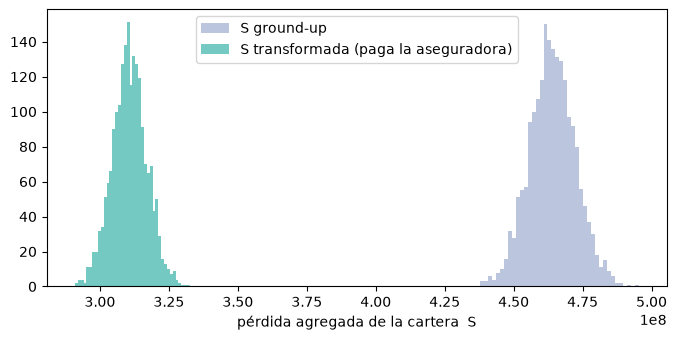

In [26]:
# ─── Simulación del modelo colectivo (ground-up y transformada) ────────────
Lambda = lam_hat * df.exposicion.sum()          # siniestros esperados en la cartera
r_agg  = Lambda / (phi - 1)                      # dispersión agregada (Var = φ·Λ)
p_agg  = r_agg / (r_agg + Lambda)
frecuencia_agg = stats.nbinom(r_agg, p_agg)

ded = df.deducible.values; sa = df.suma_asegurada.values; coas = df.coaseguro.values
M = 2000
Sg = np.empty(M); Sp = np.empty(M)
for m in range(M):
    Ntot = frecuencia_agg.rvs()
    xg = dist_sev.rvs(*pr_sev, size=Ntot)
    pol = np.random.randint(0, len(df), Ntot)
    xp = transformar(xg, ded[pol], coas[pol], sa[pol])
    Sg[m] = xg.sum(); Sp[m] = xp.sum()

def resumen(S):
    v = np.percentile(S, 99); return S.mean(), v, S[S > v].mean()
print(f"Siniestros esperados en la cartera (Λ) = {Lambda:,.0f}\n")
print(f"{'Versión':14}{'E[S] (prima pura)':>20}{'VaR99':>16}{'TVaR99':>16}")
for nom, S in [("Ground-up", Sg), ("Transformada", Sp)]:
    e, v, t = resumen(S)
    print(f"{nom:14}{e:>20,.0f}{v:>16,.0f}{t:>16,.0f}")
print(f"\nLa póliza (deducible+límite) reduce la prima pura de la cartera un "
      f"{1 - Sp.mean()/Sg.mean():.1%}: esa es la S que sirve para tarificar el producto.")

plt.hist(Sg, bins=40, alpha=0.6, color="#8FA0C8", label="S ground-up")
plt.hist(Sp, bins=40, alpha=0.6, color="#17A69B", label="S transformada (paga la aseguradora)")
plt.xlabel("pérdida agregada de la cartera  S"); plt.legend(); plt.show()

> **Lectura del resultado:** a nivel de **toda la cartera** (miles de siniestros), la ley de los grandes
> números hace que S sea muy estable: el VaR99 queda solo ~4–5% por encima de E[S]. Ese porcentaje es,
> justamente, el **recargo de seguridad** que cubriría el percentil 99 de la cartera. El pooling reduce el
> riesgo *relativo* —esa es la esencia del seguro—; la cola pesa mucho más en carteras chicas y en el
> reaseguro (Tema 5).

---
## 5. Validación contra la guía de ramos (Sesión 6)

Contrasto lo obtenido con el perfil de mercado de **autos** de la guía.

In [27]:
# ─── Contraste con el perfil de la guía de ramos ───────────────────────────
print("Guía de ramos (Autos)      vs.   Esta cartera")
print("-" * 55)
print(f"frecuencia: la más alta      →   λ̂ = {lam_hat:.2f}/año-póliza (alta ✓)")
print(f"severidad: moderada          →   media ≈ {con.monto_promedio_siniestro.mean():,.0f} (moderada ✓)")
print(f"cola: media                  →   {mejor} elegida (cola media ✓)")
print(f"frecuencia: Poisson/NB       →   sobredispersión → NB ✓")
print("\nConclusión: la cartera es consistente con el perfil de mercado del ramo.")

Guía de ramos (Autos)      vs.   Esta cartera
-------------------------------------------------------
frecuencia: la más alta      →   λ̂ = 0.37/año-póliza (alta ✓)
severidad: moderada          →   media ≈ 52,471 (moderada ✓)
cola: media                  →   Lognormal elegida (cola media ✓)
frecuencia: Poisson/NB       →   sobredispersión → NB ✓

Conclusión: la cartera es consistente con el perfil de mercado del ramo.


---
## 6. Preguntas de introducción *(ejemplo de respuesta)*

- **¿Por qué el ramo?** 
  El ramo correspondiente al Seguro de Automóviles nos pareció interesante por los siguientes tres principales puntos: 
  - **Estabilidad de la información**: Dado que estamos hablando de un riesgo con exposición diaria, el ramo genera una gran densidad de información con la cual es más fácil de trabajar. Este volumen de datos provoca que se disminuya la volatilidad y garantiza una credibilidad estadística. Además, la frecuencia constante nos dicta el comportamiento de cierta región, como lo puede ser una urbanización, explicando de alguna manera cuál es su dinámica social; de esta manera también nos es fácil aplicar una segmentación precisa, ya sea por modelo, año, o marca.
  - **Adaptabilidad y flexibilidad del modelado**: Se ha encontrado que las reclamaciones de autos de forma natural se acopla a distribuciones paramétricas conocidas. Además, la existencia de un deducible genera un truncamiento en nuestros datos, en donde se filtraran aquellos siniestros que sean menores a una tarifa establecida, este comportamiento se ajusta a modelos de severidad robusta como lo puede ser la Lognormal, o inclusive la Gamma (para la severidad) . De igual manera, se encontró que la frecuencia de estas reclamaciones se adaptan fácilmente a herramientas como la distribución Poisson (para frecuencia).
  - **Diseño estratégico**: Puesto que el mercado actual ofrece un amplio marco de referencia para nuestro producto, nos sirve como guía en el funcionamiento de las coberturas principales, de esta manera poder generar una base sólida que compita con los mejores referentes, en cuanto a coberturas estándares, dejando un margen para innovar y añadir un sello característico y distintivo de nuestro producto. 
- **¿Qué coberturas?**
Para nuestro producto se piensa incluir principalmente las siguientes: 
  - **Responsabilidad Civil a Terceros**: Cobertura básica para este ramo. Con este se busca cubrir daños que puedan ocurrir a propiedades ajenas así como lesiones o muerte a terceros. Con lo anterior, esta cobertura resulta fundamental ya que va a amparar indemnizaciones a este tipo de daños que puedan ser ocasionados. Se va a definir tomando en cuenta un límite máximo de responsabilidad o suma asegurada global.  La cobertura de RC va a proteger al asegurado haciendo frente a los compromisos legales que se deriven del accidente que afecte a terceros. El costo o valor actuarial va a depender del perfil de riesgo, pues los daños a terceros varían desde reclamos menores hasta liquidaciones extremas (ya sea por daño, incapacidad o fallecimiento). La Responsabilidad Civil desde el punto estadístico introducirá en nuestro modelo una mayor dispersión y una cola de severidad más pesada o extendida, lo cual nos pone en un escenario ideal para modelar eventos que tengan un impacto económico de importancia y facilite estudiar su comportamiento hablando de riesgo en valores dentro de la cartera. 
  - **Daños materiales al vehículo**: Protege el patrimonio del asegurado ante cualquier daño físico que pueda sufrir su vehículo. Va a amparar las pérdidas parciales ocasionadas al vehículo por accidentes de tránsito, volcaduras, o contingencias climatológicas.  El costo máximo está acotado por el valor real del vehículo, lo que delimita el recorrido de la variable aleatoria. Requiere la aplicación de un deducible que permite estudiar el efecto de truncamiento en la distribución de pérdidas, esto descarta reclamaciones menores y resulta de manera más eficaz conseguir una mayor consistencia estadística en la siniestralidad total, es decir, optimiza el costo medio del siniestro que impacta en reservas de la compañía (se logra un mejor ajuste en distribuciones continuas como lo es la Lognormal y Gamma).   
  - **Asistencia vial y legal**: Esta cobertura lo que busca es ayudar al asegurado en cuanto a  gastos relacionados con el transporte de las unidades dañadas, es decir, cubre el pago de grúas, de igual forma paga los honorarios de los abogados o fianzas por si se tiene algún problema legal por un choque. En su mayoría esta cobertura funciona a través de empresas de terceros, en donde se contratan servicios legales/grúas por alguna tarifa fija.
  - **Robo total**: Representa pérdidas totales y golpea directamente el valor comercial completo del coche. Indemnizará al asegurado en caso de que la unidad sea robada por completo; la segmentación por marca, año, modelo, etc. jugará un papel importante en cuanto a la frecuencia del siniestro, pues estadísticamente existen modelos que son más robados que otros. Desde el punto de vista de la modelación estadística, la severidad del riesgo cuenta con una cota superior que se va a determinar por la suma asegurada del auto (jamás se pagará más de lo que vale el auto), esto evita colas infinitas y nos permite definir de forma más precisa nuestro dominio donde se encontrará la variable aleatoria, es decir, nos restringe el soporte de nuestra distribución de probabilidad a un intervalo finito. Puesto que en caso de ocurrir el siniestro se paga el valor total de la unidad asegurada, la severidad recae completamente en la frecuencia que se tenga de los siniestros. Una distribución Binomial Negativa se adapta perfectamente a la  naturaleza de los siniestros, pues al ser segmentados por marca, y modelo, se induce una heterogeneidad, la cual se traduce estadísticamente en sobredispersión. La flexibilidad con la que cuenta la Distribución Binomial Negativa permite capturar con mayor precisión las diferencias en la probabilidad de un siniestro entre los distintos perfiles de los vehículos.
  - **Gastos médicos a ocupantes**: Se busca cubrir la atención médica de las personas que viajan dentro del coche asegurado al momento del siniestro, con ello las cuentas de hospitales, ambulancias y medicamentos. Todo esto a partir de una cláusula en donde se define como se pagarán estos servicios, ya sea por reembolso o pago directo, además de definir un límite estricto de estos gastos, ya sea por persona o por evento.  Dentro del modelado se tiene que esta variable aumentará si la frecuencia de daños materiales aumenta, en ese sentido se comporta de manera dependiente; se requiere de ajustes que dependen de aquellos límites estrictos por persona o evento. De esta manera se estará trabajando con una distribución de la severidad Lognormal, la cual tendrá una censura por la derecha, ya que el límite máximo acota la cola pesada, impidiendo que el algoritmo se descontrole con los valores extremos.

## 7. Conclusión

- **Severidad:** lognormal (por AIC y cola). E[X] ground-up ≈ el de la tabla; tras la póliza baja por el deducible.
- **Frecuencia:** binomial negativa (sobredispersión clara, φ>1, menor AIC).
- **Prima pura del producto:** E[S] de la versión **transformada** (la que paga la aseguradora).
- La cartera cuadra con el perfil de autos de la guía de ramos.